<a href="https://colab.research.google.com/github/dcthyun0308/ESAA/blob/main/Ob_3_project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 스태킹

In [1]:
!pip install -q lightgbm xgboost catboost

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import StackingRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_log_error, make_scorer

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
!pip install catboost
from catboost import CatBoostRegressor

In [2]:
df = pd.read_csv('insurance.csv')

In [3]:
# 전처리

# region 제거
df = df.drop(columns=["region"], errors="ignore")

# 파생변수 추가
df["is_obese"] = (df["bmi"] >= 30).astype(int)
df["is_smoker"] = (df["smoker"] == "yes").astype(int)
df["obese_smoker"] = df["is_obese"] * df["is_smoker"]

X = df.drop(columns=["charges"])
y = np.log1p(df["charges"])   # 타깃 로그변환

# 컬럼 구분
categorical_features = ["sex", "smoker"]
numeric_features = [col for col in X.columns if col not in categorical_features]

# 전처리 파이프라인
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [4]:
def rmsle(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

rmsle_scorer = make_scorer(rmsle, greater_is_better=False)

In [5]:
# Base model
xgb_model = XGBRegressor(
    n_estimators=900,
    learning_rate=0.02,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.05,
    reg_lambda=3,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

lgbm_model = LGBMRegressor(
    n_estimators=700,
    learning_rate=0.03,
    max_depth=4,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

cat_model = CatBoostRegressor(
    iterations=800,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=3,
    loss_function="RMSE",
    verbose=0,
    random_state=42
)

gbr_model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    random_state=42
)

ridge_model = Ridge(alpha=3.0)

In [6]:
# Stacking 1_XGB + CatBoost + LGBM + Ridge
stacking_model = StackingRegressor(
    estimators=[
        ("xgb", xgb_model),
        ("lgbm", lgbm_model),
        ("cat", cat_model),
        ("ridge", ridge_model)
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1,
    passthrough=False
)

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("stacking", stacking_model)
])


In [7]:
# Stacking 1 검증
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = -cross_val_score(pipe, X, y, cv=kf, scoring=rmsle_scorer, n_jobs=-1)

print("Fold RMSLE:", cv_scores)
print("Mean RMSLE:", cv_scores.mean())

Fold RMSLE: [0.35438833 0.39562064 0.36261966 0.39077337 0.40961557]
Mean RMSLE: 0.382603514349228


In [8]:
# Stacking1 passthrough=True
stacking_model = StackingRegressor(
    estimators=[
        ("xgb", xgb_model),
        ("lgbm", lgbm_model),
        ("cat", cat_model),
        ("ridge", ridge_model)
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1,
    passthrough=True
)

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("stacking", stacking_model)
])

In [9]:
# Stacking 1 passthrough 검증
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = -cross_val_score(pipe, X, y, cv=kf, scoring=rmsle_scorer, n_jobs=-1)

print("Fold RMSLE:", cv_scores)
print("Mean RMSLE:", cv_scores.mean())

Fold RMSLE: [0.35438882 0.39615513 0.36237409 0.39132808 0.40966065]
Mean RMSLE: 0.3827813544521105


In [10]:
# Stacking2_XGB + LGBM + GBR + Ridge
stacking_model = StackingRegressor(
    estimators=[
        ("xgb", xgb_model),
        ("lgbm", lgbm_model),
        ("gbr", gbr_model),
        ("ridge", ridge_model)
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1,
    passthrough=False
)

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("stacking", stacking_model)
])

In [11]:
# Stacking2 검증
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = -cross_val_score(pipe, X, y, cv=kf, scoring=rmsle_scorer, n_jobs=-1)

print("Fold RMSLE:", cv_scores)
print("Mean RMSLE:", cv_scores.mean())

Fold RMSLE: [0.35326058 0.39094594 0.36261396 0.39032144 0.40862172]
Mean RMSLE: 0.38115272824053453


In [12]:
# Stacking2_passthrough = True
stacking_model = StackingRegressor(
    estimators=[
        ("xgb", xgb_model),
        ("lgbm", lgbm_model),
        ("gbr", gbr_model),
        ("ridge", ridge_model)
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1,
    passthrough=True
)

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("stacking", stacking_model)
])

In [13]:
# Stacking2 passthrough = True 검증
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = -cross_val_score(pipe, X, y, cv=kf, scoring=rmsle_scorer, n_jobs=-1)

print("Fold RMSLE:", cv_scores)
print("Mean RMSLE:", cv_scores.mean())

Fold RMSLE: [0.35329031 0.39147829 0.36235984 0.39061681 0.40895052]
Mean RMSLE: 0.38133915267121093


In [14]:
# Stacking3_lgbm + cat + gbr + ridge
stacking_model = StackingRegressor(
    estimators=[
        ("lgbm", lgbm_model),
        ("cat", cat_model),
        ("gbr", gbr_model),
        ("ridge", ridge_model)
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1,
    passthrough=False
)

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("stacking", stacking_model)
])

In [15]:
# Stacking3 검증
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = -cross_val_score(pipe, X, y, cv=kf, scoring=rmsle_scorer, n_jobs=-1)

print("Fold RMSLE:", cv_scores)
print("Mean RMSLE:", cv_scores.mean())

Fold RMSLE: [0.35550191 0.39433947 0.36570443 0.39033693 0.40904964]
Mean RMSLE: 0.3829864772576328


In [16]:
# Stacking3_passing through = True
stacking_model = StackingRegressor(
    estimators=[
        ("lgbm", lgbm_model),
        ("cat", cat_model),
        ("gbr", gbr_model),
        ("ridge", ridge_model)
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1,
    passthrough=True
)

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("stacking", stacking_model)
])

In [17]:
# Stacking3 passing through = True검증
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = -cross_val_score(pipe, X, y, cv=kf, scoring=rmsle_scorer, n_jobs=-1)

print("Fold RMSLE:", cv_scores)
print("Mean RMSLE:", cv_scores.mean())

Fold RMSLE: [0.35557431 0.39471302 0.36566434 0.39055745 0.40932604]
Mean RMSLE: 0.3831670312451234


# 앙상블

In [18]:
import pandas as pd
import numpy as np

In [19]:
!pip install catboost

In [21]:
df = pd.read_csv('insurance.csv')

In [22]:
df = df.drop(columns=['region'])
df['charges'] = np.log1p(df['charges'])

In [23]:
from sklearn.model_selection import train_test_split
import numpy as np

idx = np.arange(len(df))

train_idx, test_idx = train_test_split(
    idx, test_size=0.2, random_state=42
)

In [24]:
df_xgb = pd.get_dummies(df, drop_first=True)

X_xgb = df_xgb.drop('charges', axis=1)
y = df_xgb['charges']

X_train_xgb = X_xgb.iloc[train_idx]
X_test_xgb = X_xgb.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

In [25]:
df_cat = df.copy()

X_cat = df_cat.drop('charges', axis=1)

X_train_cat = X_cat.iloc[train_idx]
X_test_cat = X_cat.iloc[test_idx]

In [26]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)

param_dist = {
    'n_estimators': [700, 900, 1100],
    'learning_rate': [0.01, 0.015, 0.02],
    'max_depth': [2, 3],
    'subsample': [0.75, 0.8, 0.85],
    'colsample_bytree': [0.75, 0.8, 0.85],
    'reg_alpha': [0, 0.05, 0.1],
    'reg_lambda': [2, 3, 4]
}

random_search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring='neg_root_mean_squared_error',
    cv=3,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_xgb, y_train)

RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.75, 0.8, 0.85],
                                        'learning_rate': [0.01, 0.015, 0.02],
                                        'max_depth': [2, 3],
                                        'n_estimators': [700, 900, 1100],
                                        'reg_alpha': [0, 0.05, 0.1],
                                        'reg_lambda': [2, 3, 4],
                                        'subsample': [0.75, 0.8, 0.85]},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [27]:
best_xgb = random_search.best_estimator_

xgb_pred = best_xgb.predict(X_test_xgb)

In [28]:
import numpy as np
from sklearn.metrics import mean_squared_error

rmsle_xgb_rs = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_pred
    )
)

print("random search XGBoost RMSE (log scale):", rmsle_xgb_rs)

random search XGBoost RMSE (log scale): 0.3489909784083606


In [29]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

cat = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=3,
    random_state=42,
    verbose=0
)

from sklearn.model_selection import train_test_split

X_tr_cat, X_val_cat, y_tr_cat, y_val_cat = train_test_split(
    X_train_cat, y_train, test_size=0.2, random_state=42
)

cat.fit(
    X_tr_cat, y_tr_cat,
    eval_set=(X_val_cat, y_val_cat),
    early_stopping_rounds=50,
    cat_features=['sex', 'smoker']
)

cat_pred = cat.predict(X_test_cat)

cat_rmse = np.sqrt(mean_squared_error(y_test, cat_pred))
print(f"CatBoost RMSLE: {cat_rmse:.4f}")

CatBoost RMSLE: 0.3510


In [30]:
from sklearn.model_selection import KFold

def objective_rf(trial):

    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 15),
        'max_features': trial.suggest_float('max_features', 0.5, 1.0),
        'random_state': 42,
        'n_jobs': -1
    }

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    oof = np.zeros(len(X_train_rf))

    for train_idx, val_idx in kf.split(X_train_rf):

        X_tr = X_train_rf.iloc[train_idx]
        X_val = X_train_rf.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        model = RandomForestRegressor(**param)
        model.fit(X_tr, y_tr)

        oof[val_idx] = model.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_train, oof))
    return rmse

In [31]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 9.9 MB/s eta 0:00:00


In [32]:
import optuna

In [33]:
X_train_rf = X_train_xgb
X_test_rf = X_test_xgb

In [36]:
from sklearn.ensemble import RandomForestRegressor

In [37]:
study_rf = optuna.create_study(direction='minimize')
study_rf.optimize(objective_rf, n_trials=50)

print("RF Best RMSE:", study_rf.best_value)
print("RF Best Params:", study_rf.best_params)

[I 2026-03-27 07:06:29,666] A new study created in memory with name: no-name-d0b16c74-2cd4-4be7-b751-c389990872dc
[I 2026-03-27 07:06:36,632] Trial 0 finished with value: 0.39575445812910903 and parameters: {'n_estimators': 417, 'max_depth': 12, 'min_samples_split': 13, 'max_features': 0.8272441168234572}. Best is trial 0 with value: 0.39575445812910903.
[I 2026-03-27 07:06:43,125] Trial 1 finished with value: 0.4198431198550498 and parameters: {'n_estimators': 402, 'max_depth': 28, 'min_samples_split': 2, 'max_features': 0.7559313775017584}. Best is trial 0 with value: 0.39575445812910903.
[I 2026-03-27 07:06:44,959] Trial 2 finished with value: 0.3936001059498541 and parameters: {'n_estimators': 158, 'max_depth': 27, 'min_samples_split': 14, 'max_features': 0.7644850494588665}. Best is trial 2 with value: 0.3936001059498541.
[I 2026-03-27 07:06:46,898] Trial 3 finished with value: 0.40636426971266326 and parameters: {'n_estimators': 156, 'max_depth': 18, 'min_samples_split': 5, 'max_

RF Best RMSE: 0.38696551590209316
RF Best Params: {'n_estimators': 110, 'max_depth': 5, 'min_samples_split': 15, 'max_features': 0.8986009173796154}


In [38]:
rf = RandomForestRegressor(
    **study_rf.best_params,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_rf, y_train)
rf_pred = rf.predict(X_test_rf)

# **XGB+CAT+RF**

In [39]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [40]:
oof_xgb = np.zeros(len(X_train_xgb))
test_pred_xgb = np.zeros(len(X_test_xgb))

oof_rf = np.zeros(len(X_train_xgb))
test_pred_rf = np.zeros(len(X_test_xgb))

for train_idx, val_idx in kf.split(X_train_xgb):

    X_tr = X_train_xgb.iloc[train_idx]
    X_val = X_train_xgb.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    model = XGBRegressor(**best_xgb.get_params())
    model.fit(X_tr, y_tr)

    oof_xgb[val_idx] = model.predict(X_val)
    test_pred_xgb += model.predict(X_test_xgb) / 5

    model_rf = RandomForestRegressor(
    **study_rf.best_params,
    random_state=42,
    n_jobs=-1
)
    model_rf.fit(X_tr, y_tr)
    pred_rf_val = model_rf.predict(X_val)
    pred_rf_test = model_rf.predict(X_test_xgb)

    oof_rf[val_idx] = pred_rf_val
    test_pred_rf += pred_rf_test / 5

In [41]:
oof_cat = np.zeros(len(X_train_cat))
test_pred_cat = np.zeros(len(X_test_cat))

cat_features = [X_train_cat.columns.get_loc(col) for col in ['sex', 'smoker']]

for train_idx, val_idx in kf.split(X_train_cat):

    X_tr = X_train_cat.iloc[train_idx]
    X_val = X_train_cat.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    model = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.03,
        depth=6,
        l2_leaf_reg=3,
        random_state=42,
        verbose=0
    )

    model.fit(
        X_tr, y_tr,
        eval_set=(X_val, y_val),
        early_stopping_rounds=50,
        cat_features=cat_features
    )

    oof_cat[val_idx] = model.predict(X_val)
    test_pred_cat += model.predict(X_test_cat) / 5

In [42]:
from sklearn.metrics import mean_squared_error

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

print("XGB OOF RMSE:", rmse(y_train, oof_xgb))
print("RF  OOF RMSE:", rmse(y_train, oof_rf))
print("CAT OOF RMSE:", rmse(y_train, oof_cat))

XGB OOF RMSE: 0.3849781276245694
RF  OOF RMSE: 0.38696551590209316
CAT OOF RMSE: 0.38249155871514096


In [43]:
best_score = 1e9
best_weights = None

for w1 in np.arange(0, 1.01, 0.1):   # XGB
    for w2 in np.arange(0, 1.01, 0.1):  # RF
        for w3 in np.arange(0, 1.01, 0.1):  # CAT

            if abs(w1 + w2 + w3 - 1) > 1e-6:
                continue

            oof_pred = (
                w1 * oof_xgb +
                w2 * oof_rf +
                w3 * oof_cat
            )

            score = rmse(y_train, oof_pred)

            if score < best_score:
                best_score = score
                best_weights = (w1, w2, w3)

print("Best Weights:", best_weights)
print("Best OOF RMSE:", best_score)

Best Weights: (np.float64(0.2), np.float64(0.2), np.float64(0.6000000000000001))
Best OOF RMSE: 0.38177105937052436


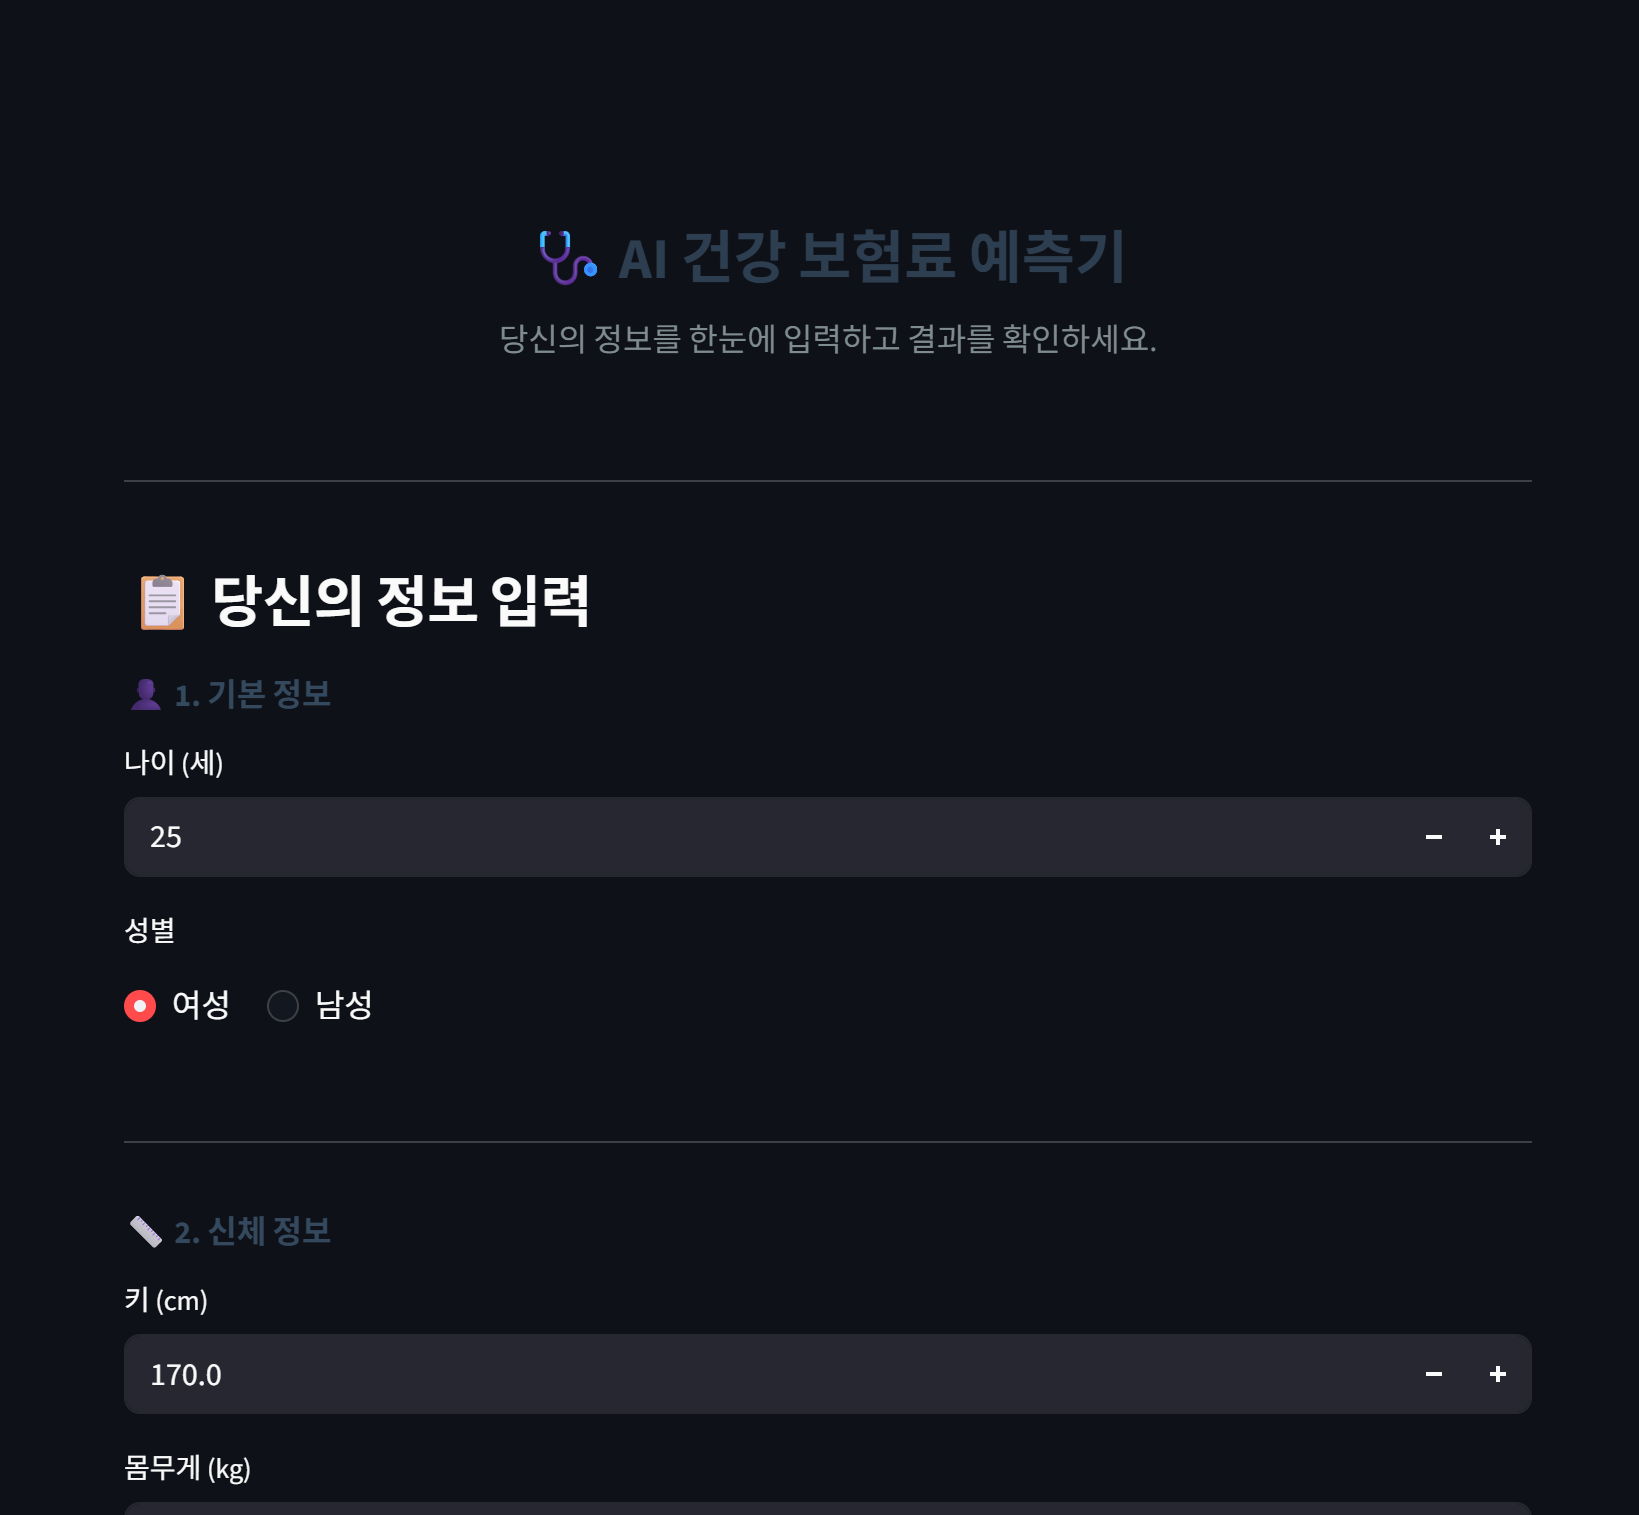

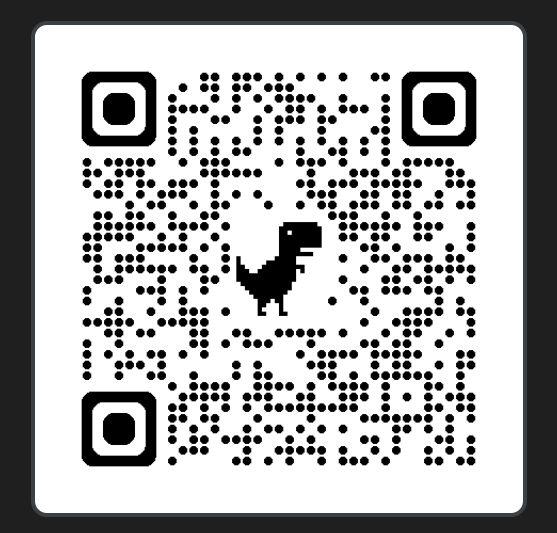